### GNNにおけるグラフ作成のためのEDA

In [13]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import os
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
import torch
import sys
import torch
import random
import math
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report   

plt.rcParams['font.family'] = 'Hiragino Sans'

csv_path = os.path.join('../data/ranking_train.csv')
json_path = os.path.join('../data/cards.json')

df = pd.read_csv(csv_path)

with open(json_path, 'r', encoding='utf-8') as f:
    cards_data = json.load(f)
    
# ID -> 名前 のマッピング辞書
id_to_name = {}
for card_id_str, name_info in cards_data.items():
    if isinstance(name_info, dict) and "name" in name_info:
        id_to_name[int(card_id_str)] = name_info["name"]
    else:
        id_to_name[int(card_id_str)] = str(name_info)

# card1 ~ card8 の列だけを抽出してリスト化
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'card7', 'card8']
decks = df[card_cols].values.tolist()

# IDを名前に変換
decks_names = []
for deck in decks:
    decks_names.append([id_to_name.get(card_id, f"Unknown({card_id})") for card_id in deck])

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations
from networkx.algorithms.community import greedy_modularity_communities

# ==========================================
# 1. データの準備（IDから名前への変換など）
# ==========================================
decks_for_eda = decks_names  

print(f" {len(decks_for_eda)} 個のデッキデータから共起行列を作成します...")

# ==========================================
# 2. 全カードの「共起行列」の作成 (エッジリスト形式)
# ==========================================
# 122x122の行列を直接作る代わりに、メモリ効率の良い「ペアと回数の辞書」を作ります
co_occurrence = {}

for deck in decks_for_eda:
    # デッキ8枚から2枚を選ぶ全組み合わせ（28通り）をカウント
    for card1, card2 in combinations(sorted(deck), 2):
        pair = (card1, card2)
        co_occurrence[pair] = co_occurrence.get(pair, 0) + 1

# ==========================================
# 3. NetworkX グラフの構築 (GNNの世界地図)
# ==========================================
G = nx.Graph()

# 一定回数以上（ノイズを除外）一緒に使われたペアだけを「繋がり」として登録
threshold = 20
for (card1, card2), weight in co_occurrence.items():
    if weight >= threshold:
        G.add_edge(card1, card2, weight=weight)

print(f"グラフ構築完了: ノード(カード)={G.number_of_nodes()}枚, エッジ(繋がり)={G.number_of_edges()}本")

# ==========================================
# 4. ネットワーク分析（GNNに教える前に人間が地図を確認する）
# ==========================================

# ① 環境の中心ハブカード（PageRank）
pagerank = nx.pagerank(G, weight='weight')
sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)
print("\n👑 環境の中心ハブカード (Top 5):")
for i, (card, score) in enumerate(sorted_pagerank[:5]):
    print(f"  {i+1}. {card} ({score:.4f})")

# ② コミュニティ（アーキタイプ）の自動検出
communities = list(greedy_modularity_communities(G, weight='weight'))
print(f"\n ネットワークから自動検出された派閥の数: {len(communities)}")
for i, comm in enumerate(communities[:10]): # 上位10つの大きな派閥を表示
    print(f"  ▶ 派閥 {i+1}: {', '.join(list(comm)[:7])} ...")

# ③ 特定カードの相棒
target_card = "Goblin Barrel"
if target_card in G:
    neighbors = sorted(G[target_card].items(), key=lambda x: x[1]['weight'], reverse=True)
    print(f"\n {target_card} の最強の相棒 (Top 5):")
    for neighbor, data in neighbors[:5]:
        print(f"  - {neighbor} (共起回数: {data['weight']})")

 619647 個のデッキデータから共起行列を作成します...
グラフ構築完了: ノード(カード)=121枚, エッジ(繋がり)=7048本

👑 環境の中心ハブカード (Top 5):
  1. Arrows (0.0330)
  2. The Log (0.0329)
  3. Valkyrie (0.0245)
  4. Mega Knight (0.0245)
  5. Fireball (0.0230)

 ネットワークから自動検出された派閥の数: 3
  ▶ 派閥 1: Wizard, Skeleton Dragons, Baby Dragon, Bowler, Magic Archer, Clone, Spear Goblins ...
  ▶ 派閥 2: Flying Machine, Bomb Tower, Graveyard, Giant Snowball, Fisherman, Ice Wizard, Giant Skeleton ...
  ▶ 派閥 3: Archer Queen, Princess, Rocket, Ice Golem, Earthquake, Inferno Tower, Royal Delivery ...

 Goblin Barrel の最強の相棒 (Top 5):
  - The Log (共起回数: 38801)
  - Dart Goblin (共起回数: 29086)
  - Princess (共起回数: 28514)
  - Goblin Gang (共起回数: 27416)
  - Knight (共起回数: 25451)


## 埋め込みベクトルのテスト

In [15]:
import json
import numpy as np

# コサイン類似度（-1.0 〜 1.0）を計算する関数
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# さきほど完成した最強の辞書を読み込む
print("📦 辞書を読み込んでいます...")
with open('../models/gcn_embeddings.json', 'r', encoding='utf-8') as f:
    embeddings = json.load(f)

print("🔍 GCNが学習した「カード同士の相性（コサイン類似度）」をテストします\n")

# 調べるカードのリスト（※英語名がデータと一致しているか確認してください）
card_A = "P.E.K.K.A"
targets = [
    "Zap",             # 神器の相棒
    "Electro Wizard",  # 神器の相棒
    "Battle Ram",      # 神器の主軸
    "Golem",           # 全く別の重い主軸
    "X-Bow",           # 全く別の戦術
    "Mega Knight"      # 全く別の主軸
]

if card_A in embeddings:
    vec_A = np.array(embeddings[card_A])
    
    for target in targets:
        if target in embeddings:
            vec_target = np.array(embeddings[target])
            sim = cosine_similarity(vec_A, vec_target)
            
            # スコアが高い（1.0に近い）ほど「同じ戦術の仲間」
            # スコアが低い（0以下）ほど「無関係」
            print(f"{card_A} ⚔️ {target:<15} : 類似度 {sim:.4f}")
        else:
            print(f"⚠️ {target} が辞書に見つかりません。")
else:
    print(f"⚠️ {card_A} が辞書に見つかりません。")

📦 辞書を読み込んでいます...
🔍 GCNが学習した「カード同士の相性（コサイン類似度）」をテストします

P.E.K.K.A ⚔️ Zap             : 類似度 1.0000
P.E.K.K.A ⚔️ Electro Wizard  : 類似度 1.0000
P.E.K.K.A ⚔️ Battle Ram      : 類似度 1.0000
P.E.K.K.A ⚔️ Golem           : 類似度 0.9998
P.E.K.K.A ⚔️ X-Bow           : 類似度 0.9989
P.E.K.K.A ⚔️ Mega Knight     : 類似度 1.0000


### 浅い埋め込み

In [21]:
# さきほど完成した最強の辞書を読み込む
print(" 辞書を読み込んでいます...")
with open('../models/gcn_embeddings_shallow.json', 'r', encoding='utf-8') as f:
    embeddings = json.load(f)

print("GCNが学習した「カード同士の相性（コサイン類似度）」をテストします\n")

# 調べるカードのリスト（※英語名がデータと一致しているか確認してください）
card_A = "P.E.K.K.A"
targets = [
    "Zap",             # 神器の相棒
    "Electro Wizard",  # 神器の相棒
    "Battle Ram",      # 神器の主軸
    "Golem",           # 全く別の重い主軸
    "X-Bow",           # 全く別の戦術
    "Goblin Barrel",   # 全く別の戦術
    "Mega Knight",      # 全く別の主軸
    "Giant Skeleton"   # 全く別の主軸
]

if card_A in embeddings:
    vec_A = np.array(embeddings[card_A])
    
    for target in targets:
        if target in embeddings:
            vec_target = np.array(embeddings[target])
            sim = cosine_similarity(vec_A, vec_target)
            
            # スコアが高い（1.0に近い）ほど「同じ戦術の仲間」
            # スコアが低い（0以下）ほど「無関係」
            print(f"{card_A} × {target:<15} : 類似度 {sim:.4f}")
        else:
            print(f"{target} が辞書に見つかりません。")
else:
    print(f" {card_A} が辞書に見つかりません。")

 辞書を読み込んでいます...
GCNが学習した「カード同士の相性（コサイン類似度）」をテストします

P.E.K.K.A × Zap             : 類似度 -0.0624
P.E.K.K.A × Electro Wizard  : 類似度 -0.3947
P.E.K.K.A × Battle Ram      : 類似度 -0.1845
P.E.K.K.A × Golem           : 類似度 -0.0313
P.E.K.K.A × X-Bow           : 類似度 0.0760
P.E.K.K.A × Goblin Barrel   : 類似度 0.1854
P.E.K.K.A × Mega Knight     : 類似度 -0.0846
P.E.K.K.A × Giant Skeleton  : 類似度 -0.0767


## GATモデルによるエンコード

In [20]:
# さきほど完成した最強の辞書を読み込む
print(" 辞書を読み込んでいます...")
with open('../models/gcn_embeddings_shallow.json', 'r', encoding='utf-8') as f:
    embeddings = json.load(f)

print("GCNが学習した「カード同士の相性（コサイン類似度）」をテストします\n")

# 調べるカードのリスト（※英語名がデータと一致しているか確認してください）
card_A = "P.E.K.K.A"
targets = [
    "Zap",             # 神器の相棒
    "Electro Wizard",  # 神器の相棒
    "Battle Ram",      # 神器の主軸
    "Golem",           # 全く別の重い主軸
    "X-Bow",           # 全く別の戦術
    "Goblin Barrel",   # 全く別の戦術
    "Mega Knight",      # 全く別の主軸
    "Giant Skeleton"   # 全く別の主軸
]

if card_A in embeddings:
    vec_A = np.array(embeddings[card_A])
    
    for target in targets:
        if target in embeddings:
            vec_target = np.array(embeddings[target])
            sim = cosine_similarity(vec_A, vec_target)
            
            # スコアが高い（1.0に近い）ほど「同じ戦術の仲間」
            # スコアが低い（0以下）ほど「無関係」
            print(f"{card_A} × {target:<15} : 類似度 {sim:.4f}")
        else:
            print(f"{target} が辞書に見つかりません。")
else:
    print(f" {card_A} が辞書に見つかりません。")

 辞書を読み込んでいます...
GCNが学習した「カード同士の相性（コサイン類似度）」をテストします

P.E.K.K.A × Zap             : 類似度 0.1286
P.E.K.K.A × Electro Wizard  : 類似度 0.2173
P.E.K.K.A × Battle Ram      : 類似度 0.2685
P.E.K.K.A × Golem           : 類似度 0.2221
P.E.K.K.A × X-Bow           : 類似度 0.0956
P.E.K.K.A × Goblin Barrel   : 類似度 0.2992
P.E.K.K.A × Mega Knight     : 類似度 0.2401
P.E.K.K.A × Giant Skeleton  : 類似度 0.1782


# 対戦データに関するデータ分析

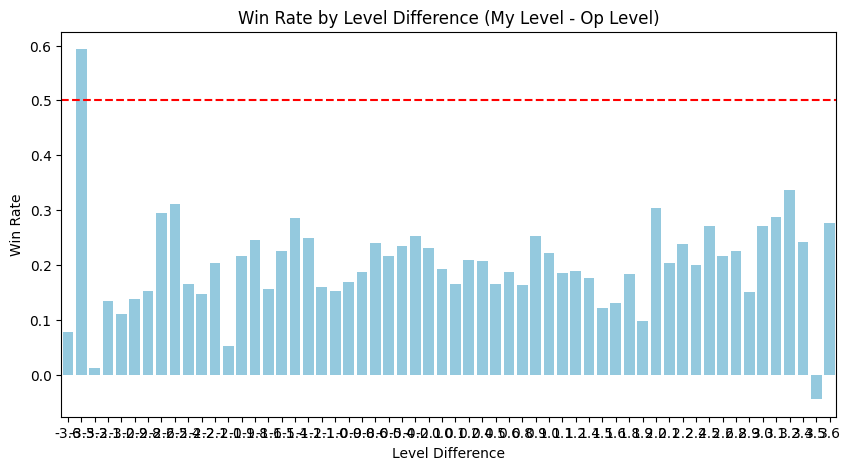

/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_19070/2581543055.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crown_diff', palette='coolwarm')


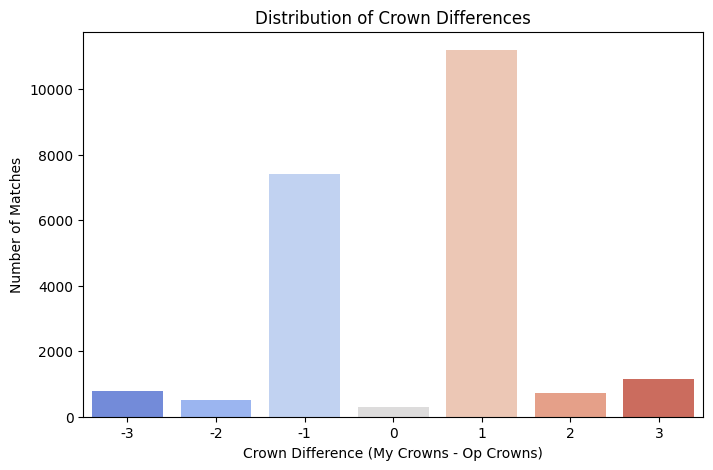

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# データの読み込み
df = pd.read_csv('../data/matches.csv')

# --- 1. レベル差と勝率の関係 ---
# レベル差を計算 (自分 - 相手)
df['level_diff'] = df['my_lev_avg'] - df['op_lev_avg']

# レベル差を0.5刻みで丸めてグループ化
df['level_diff_bin'] = df['level_diff'].round(1)
win_rates = df.groupby('level_diff_bin')['result'].mean()
counts = df.groupby('level_diff_bin')['result'].count()

# 十分なデータ数（例：50試合以上）があるビンだけを抽出
valid_bins = counts[counts >= 50].index
win_rates_filtered = win_rates[valid_bins]

plt.figure(figsize=(10, 5))
sns.barplot(x=win_rates_filtered.index, y=win_rates_filtered.values, color='skyblue')
plt.title('Win Rate by Level Difference (My Level - Op Level)')
plt.xlabel('Level Difference')
plt.ylabel('Win Rate')
plt.axhline(0.5, color='red', linestyle='--') # 勝率50%のライン
plt.show()

# --- 2. 決着のつき方（クラウン差）の分布 ---
# クラウン差を計算 (自分 - 相手)
df['crown_diff'] = df['my_crowns'] - df['op_crowns']

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crown_diff', palette='coolwarm')
plt.title('Distribution of Crown Differences')
plt.xlabel('Crown Difference (My Crowns - Op Crowns)')
plt.ylabel('Number of Matches')
plt.show()

/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_19070/3902893218.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_usage, x='usage_rate', y='name', palette='viridis')


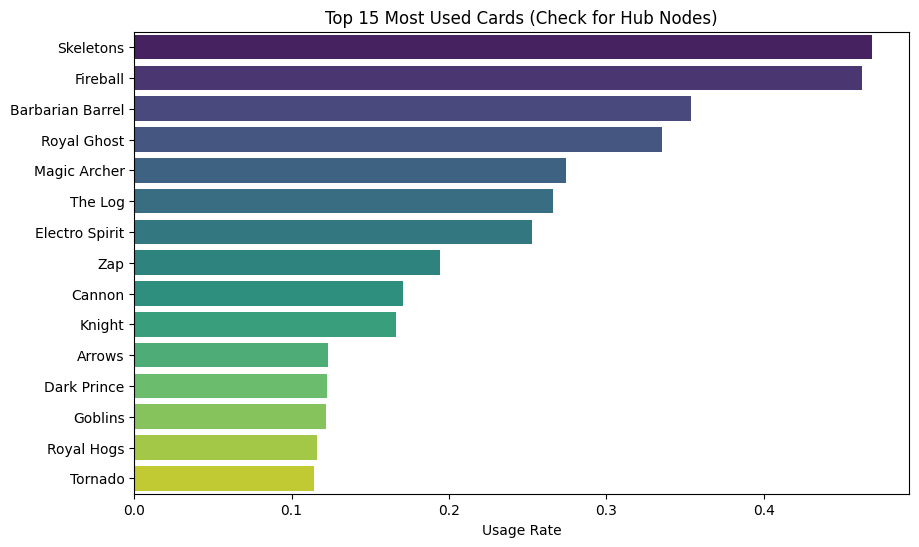

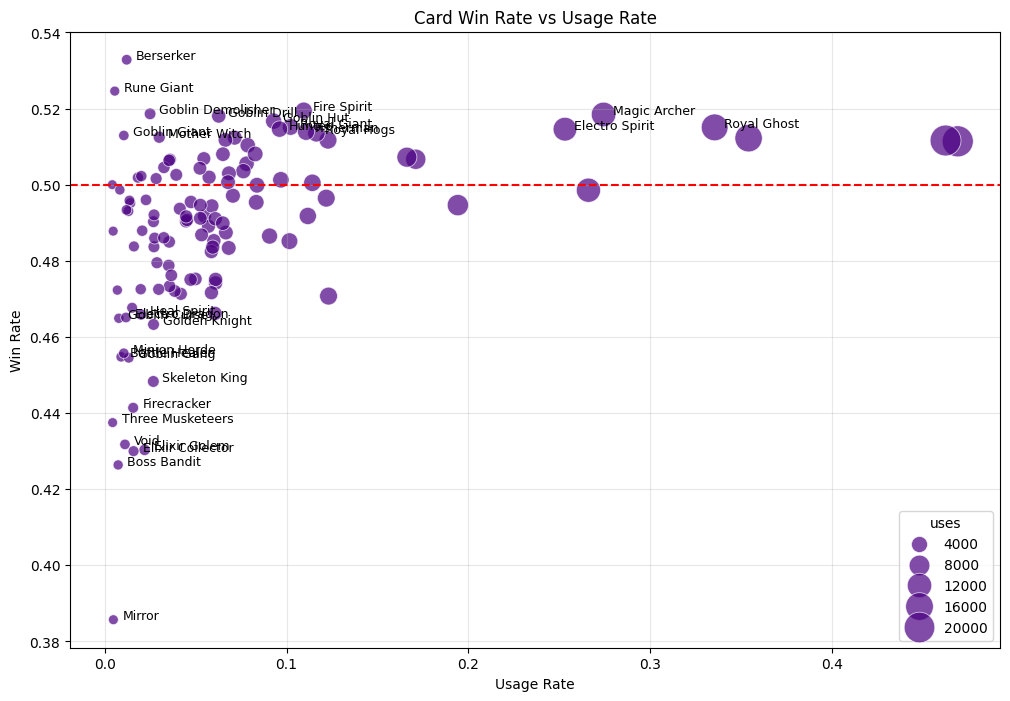

In [7]:
import json
from collections import defaultdict

# --- 3. カードの基本統計（使用率・勝率）の集計 ---
# JSONデータの読み込み
with open('../data/cards.json', 'r', encoding='utf-8') as f:
    cards_data = json.load(f)

# ID変換辞書の作成
id_to_name = {int(k): v.get('name', f"Unknown_{k}") for k, v in cards_data.items()}
id_to_cost = {int(k): v.get('elixirCost', 0) for k, v in cards_data.items()}

my_cols = [f'my_{i}' for i in range(8)]
op_cols = [f'op_{i}' for i in range(8)]

card_stats = defaultdict(lambda: {'uses': 0, 'wins': 0})
total_matches = len(df)

# 全試合をループして集計
for _, row in df.iterrows():
    is_win = (row['result'] == 1)
    
    for col in my_cols:
        card = row[col]
        card_stats[card]['uses'] += 1
        if is_win: card_stats[card]['wins'] += 1
            
    for col in op_cols:
        card = row[col]
        card_stats[card]['uses'] += 1
        if not is_win: card_stats[card]['wins'] += 1

# データフレーム化
stats_list = []
for card_id, stats in card_stats.items():
    uses = stats['uses']
    stats_list.append({
        'id': card_id,
        'name': id_to_name.get(card_id, str(card_id)),
        'cost': id_to_cost.get(card_id, 0),
        'uses': uses,
        'usage_rate': uses / (total_matches * 2),
        'win_rate': stats['wins'] / uses if uses > 0 else 0
    })

df_cards = pd.DataFrame(stats_list)

# --- グラフ描画A：使用率トップ15 ---
top_usage = df_cards.sort_values('usage_rate', ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_usage, x='usage_rate', y='name', palette='viridis')
plt.title('Top 15 Most Used Cards (Check for Hub Nodes)')
plt.xlabel('Usage Rate')
plt.ylabel('')
plt.show()

# --- グラフ描画B：使用率 vs 勝率の散布図 ---
# 試行回数が少ないノイズを除外（例：100回以上）
valid_cards = df_cards[df_cards['uses'] > 100]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=valid_cards, x='usage_rate', y='win_rate', 
                size='uses', sizes=(50, 500), alpha=0.7, color='indigo')
plt.axhline(0.5, color='red', linestyle='--')

# 勝率上位15枚と下位15枚にテキストラベルを付ける
top15_win = valid_cards.nlargest(15, 'win_rate')
bot15_win = valid_cards.nsmallest(15, 'win_rate')
for _, row in pd.concat([top15_win, bot15_win]).iterrows():
    plt.text(row['usage_rate'] + 0.005, row['win_rate'], row['name'], fontsize=9)

plt.title('Card Win Rate vs Usage Rate')
plt.xlabel('Usage Rate')
plt.ylabel('Win Rate')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_19070/3273801297.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_pairs, x='win_rate', y='pair', palette='Reds_r')


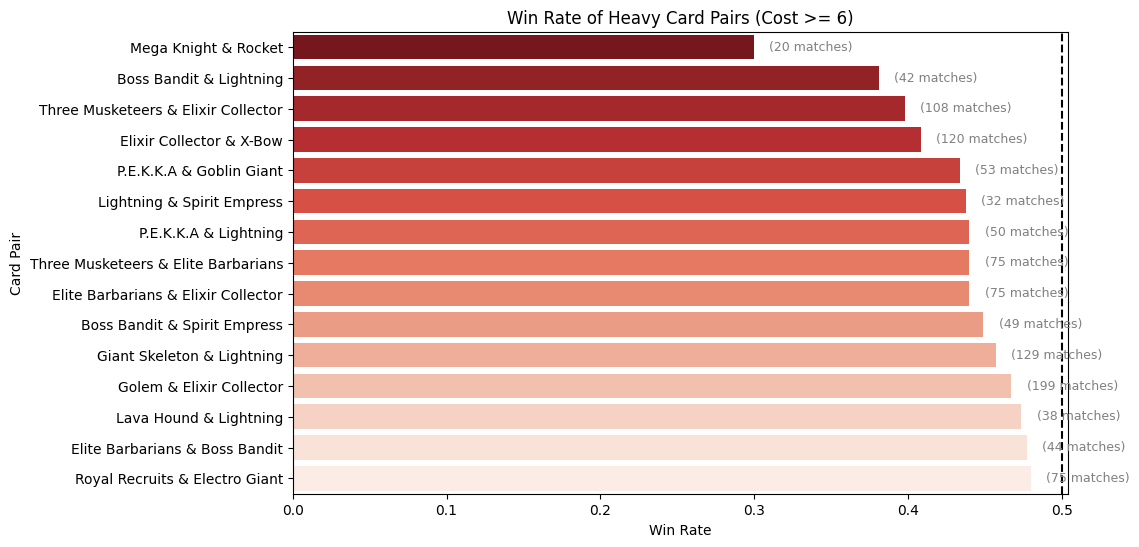

In [8]:
import itertools

# --- 4. 重コスト（コスト6以上）共起デッキの分析 ---
heavy_pairs = defaultdict(lambda: {'matches': 0, 'wins': 0})

for _, row in df.iterrows():
    my_deck = [row[col] for col in my_cols]
    op_deck = [row[col] for col in op_cols]
    is_win = (row['result'] == 1)

    for deck, win_flag in [(my_deck, is_win), (op_deck, not is_win)]:
        # コスト6以上のカードだけを抽出
        heavy_cards = [c for c in deck if id_to_cost.get(c, 0) >= 6]
        
        # 2枚以上入っていたら組み合わせを集計
        if len(heavy_cards) >= 2:
            for c1, c2 in itertools.combinations(sorted(heavy_cards), 2):
                heavy_pairs[(c1, c2)]['matches'] += 1
                if win_flag: heavy_pairs[(c1, c2)]['wins'] += 1

# データフレーム化
pair_list = []
for (c1, c2), stats in heavy_pairs.items():
    if stats['matches'] >= 20:  # ノイズ除外（20試合以上使われた組み合わせ）
        pair_list.append({
            'pair': f"{id_to_name.get(c1, str(c1))} & {id_to_name.get(c2, str(c2))}",
            'matches': stats['matches'],
            'win_rate': stats['wins'] / stats['matches']
        })

df_pairs = pd.DataFrame(pair_list)

# --- グラフ描画C：重コストペアの勝率ワースト ---
if not df_pairs.empty:
    worst_pairs = df_pairs.sort_values('win_rate', ascending=True).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=worst_pairs, x='win_rate', y='pair', palette='Reds_r')
    plt.axvline(0.5, color='black', linestyle='--')
    plt.title('Win Rate of Heavy Card Pairs (Cost >= 6)')
    plt.xlabel('Win Rate')
    plt.ylabel('Card Pair')
    
    # バーの横に試合数をテキストで表示
    for i, (val, match) in enumerate(zip(worst_pairs['win_rate'], worst_pairs['matches'])):
        plt.text(val + 0.01, i + 0.1, f"({match} matches)", fontsize=9, color='gray')
        
    plt.show()
else:
    print("重コストが2枚以上入ったデッキのデータが十分にありませんでした。")